# Startups Portugal - Exploration & Preprocess

This notebook covers Phase 1 (Audit & Exploration) and Phase 2–4 (Cleaning, Aggregation, Export) of the Dealroom startup dataset. It produces three clean CSV outputs for downstream analysis.

Plan (Gonçalo):

Phase 1 — Audit & Exploration

Phase 2 — Clean & Transform
- 2.1 Filter scope
- 2.2 Fix quality issues
- 2.3 Parse & extract features
- 2.4 Feature engineering
  
Phase 3 — Aggregation
- 3.1 Group by municipality
- 3.2 Group by district
  
Phase 4 — Export
- 4.1 Save clean CSVs
- 4.2 Document schema

# Phase 1 - Audit & Exploration

## Import

The goal of this phase is to understand the raw dataset before making any cleaning decisions.
We document missingness, scope, and data quality issues that will justify every decision in Phase 2.

**Dataset:** `Startup_Portugal2.xlsx` — Dealroom export, Portuguese startup ecosystem  
**Rows/Columns:** 4,156 × 19

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Display settings — show all columns, limit row truncation
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)

# Load dataset as df_raw
df_raw = pd.read_excel("Startup_Portugal2.xlsx")

# Always work on a copy — preserve the raw object untouched for reference
df = df_raw.copy()

df

,Name,HQ region,HQ country,HQ state,HQ city,Custom HQ regions,Founding location,Total funding (EUR M),Launch year,Launch month,Industries,Sub industries,Employees Range,Each round type,Each round amount,Each round currency,Each round date,Each round investors,Company status
0,RDfine,Europe,Portugal,Coimbra,Coimbra,Coimbra District;EU27;European Union + UK;European Union...,NaN,NaN,2023.0,NaN,health,NaN,'2-10,NaN,NaN,NaN,NaN,NaN,operational
1,Conduril,Europe,Portugal,Aveiro,Águeda,EU27;European Union + UK;European Union;G20;OECD (Organi...,NaN,NaN,1959.0,NaN,real estate,NaN,'51-200,IPO,NaN,EUR,aug/2000,NaN,operational
2,BackChain,Europe,Portugal,Porto,Porto,"Porto Metropolitan Area;Lugar do Espido, Maia;EU27;Europ...",NaN,NaN,2018.0,NaN,security,NaN,'2-10,NaN,NaN,NaN,NaN,NaN,operational
3,Liveplace,Europe,Portugal,Guarda,Sabugal,EU27;European Union + UK;European Union;G20;OECD (Organi...,NaN,NaN,1996.0,NaN,real estate,NaN,'51-200,ACQUISITION,NaN,USD,oct/2025,Grupo R Vilar,acquired
4,Inspiring,Europe,Portugal,Lisbon,Lisbon,Lisbon Metropolitan Area;EU27;European Union + UK;Europe...,NaN,NaN,2010.0,NaN,marketing,NaN,'11-50,NaN,NaN,NaN,NaN,NaN,operational
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4151,SF SYSTEM,Europe,Portugal,Madeira,NaN,EU27;European Union + UK;European Union;G20;OECD (Organi...,NaN,NaN,2022.0,NaN,enterprise software,NaN,'11-50,NaN,NaN,NaN,NaN,NaN,operational
4152,See Health,Europe,Portugal,Madeira,Funchal,EU27;European Union + UK;European Union;G20;OECD (Organi...,NaN,NaN,2020.0,NaN,health;enterprise software,NaN,'1,NaN,NaN,NaN,NaN,NaN,operational
4153,Missing Link,Europe,Portugal,Coimbra,Coimbra,Coimbra District;EU27;European Union + UK;European Union...,NaN,NaN,2020.0,NaN,NaN,NaN,'2-10,NaN,NaN,NaN,NaN,NaN,operational
4154,thecodex.world,Europe,Portugal,Lisbon,Lisbon,Lisbon Metropolitan Area;EU27;European Union + UK;Europe...,NaN,NaN,2023.0,6.0,sports,NaN,'2-10,NaN,NaN,NaN,NaN,NaN,operational


### Basic Exploration

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4156 entries, 0 to 4155
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name                   4156 non-null   object 
 1   HQ region              4156 non-null   object 
 2   HQ country             4156 non-null   object 
 3   HQ state               4089 non-null   object 
 4   HQ city                4055 non-null   object 
 5   Custom HQ regions      4156 non-null   object 
 6   Founding location      142 non-null    object 
 7   Total funding (EUR M)  701 non-null    float64
 8   Launch year            3841 non-null   float64
 9   Launch month           1328 non-null   float64
 10  Industries             3630 non-null   object 
 11  Sub industries         1582 non-null   object 
 12  Employees Range        3505 non-null   object 
 13  Each round type        1535 non-null   object 
 14  Each round amount      925 non-null    object 
 15  Each

In [4]:
# Numeric summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Total funding (EUR M),701.0,8.157318,47.670807,0.0,0.1,0.6,3.0,716.82
Launch year,3841.0,2013.818797,15.986272,1520.0,2012.0,2017.0,2021.0,2026.00
Launch month,1328.0,5.674699,3.532545,1.0,2.0,5.0,9.0,12.00


In [5]:
# Categorical summary
obj_cols = df.select_dtypes(include="object").columns
df[obj_cols].describe().T

,count,unique,top,freq
Name,4156,4149,Ferstone,2
HQ region,4156,5,Europe,4127
HQ country,4156,13,Portugal,4107
HQ state,4089,38,Lisbon,1831
HQ city,4055,186,Lisbon,1484
Custom HQ regions,4156,29,Lisbon Metropolitan Area;EU27;European Union + UK;Europe...,1858
Founding location,142,46,Portugal;Lisbon,34
Industries,3630,235,enterprise software,347
Sub industries,1582,296,health platform,99
Employees Range,3505,10,'2-10,1616


### Check for duplicates

In [6]:
df[df.duplicated()]

,Name,HQ region,HQ country,HQ state,HQ city,Custom HQ regions,Founding location,Total funding (EUR M),Launch year,Launch month,Industries,Sub industries,Employees Range,Each round type,Each round amount,Each round currency,Each round date,Each round investors,Company status


No duplicates found.

### Missing values

In [7]:
# Missing values check

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).query("`Missing Count` > 0").sort_values("Missing %", ascending=False)

print(missing_df if not missing_df.empty else "No missing values found ✅")

                       Missing Count  Missing %
Founding location               4014      96.58
Total funding (EUR M)           3455      83.13
Each round amount               3231      77.74
Launch month                    2828      68.05
Each round investors            2740      65.93
Each round type                 2621      63.07
Sub industries                  2574      61.93
Each round currency             2570      61.84
Each round date                 2567      61.77
Employees Range                  651      15.66
Industries                       526      12.66
Launch year                      315       7.58
HQ city                          101       2.43
HQ state                          67       1.61
Company status                    15       0.36


### Sample check

In [8]:
df.sample(5)

,Name,HQ region,HQ country,HQ state,HQ city,Custom HQ regions,Founding location,Total funding (EUR M),Launch year,Launch month,Industries,Sub industries,Employees Range,Each round type,Each round amount,Each round currency,Each round date,Each round investors,Company status
1852,Viveel,Europe,Portugal,Lisbon,Lisbon,Lisbon Metropolitan Area;EU27;European Union + UK;Europe...,NaN,0.1,2020.0,NaN,security,NaN,'1,SEED,0.1,EUR,jan/2023,NaN,operational
1677,Noocity,Europe,Portugal,Porto,Porto,"Porto Metropolitan Area;Lugar do Espido, Maia;EU27;Europ...",NaN,1.8,2012.0,11.0,food,agritech,'11-50,EARLY VC;SEED;SEED;SEED;SEED;SPINOUT,n/a;0.9;0.9;n/a;n/a;n/a,USD;EUR;EUR;USD;USD;USD,jun/2019;jan/2019;2019;mar/2018;jun/2016;jan/2016,;;Portugal Ventures;REDangels;REDangels;University of Porto,operational
799,Martifer,Europe,Portugal,Viseu,Oliveira de Frades,EU27;European Union + UK;European Union;G20;OECD (Organi...,NaN,NaN,1990.0,2.0,energy,NaN,'1001-5000,SECONDARY;SECONDARY;POST IPO EQUITY;IPO,n/a;38.4;6.29;n/a,USD;EUR;EUR;EUR,apr/2026;oct/2024;feb/2024;jul/2007,Grupo Visabeira;Grupo Visabeira;Black and Blue Investime...,operational
325,Clube de Autores,Europe,Portugal,Lisbon,Cascais,Lisbon Metropolitan Area;EU27;European Union + UK;Europe...,Brazil;Joinville,NaN,2009.0,5.0,education,NaN,'51-200,NaN,NaN,NaN,NaN,NaN,operational
312,Mixtalker,Europe,Portugal,Lisbon,Lisbon,Lisbon Metropolitan Area;EU27;European Union + UK;Europe...,NaN,NaN,2016.0,9.0,music;marketing,NaN,'2-10,NaN,NaN,NaN,NaN,NaN,operational


## In-depth Exploration

### Quick checks

In [9]:
# HQ country check
df["HQ country"].value_counts()

HQ country
Portugal          4107
United States       25
United Kingdom      10
Spain                3
Germany              3
Canada               1
Hong Kong            1
Nigeria              1
Switzerland          1
Australia            1
Denmark              1
Romania              1
Sweden               1
Name: count, dtype: int64

In [10]:
# HQ region (expect: always Europe)
df["HQ region"].value_counts()

HQ region
Europe           4127
North America      26
Asia                1
Africa              1
Oceania             1
Name: count, dtype: int64

In [11]:
df["Company status"].value_counts()

Company status
operational     3280
closed           447
acquired         283
low-activity     131
Name: count, dtype: int64

In [12]:
# Founding location (expect: ~96% missing) 
print(f"Non-null entries: {df['Founding location'].notna().sum()}")
print(df["Founding location"].dropna().head(5))
print()

Non-null entries: 142
32              Portugal;Lisbon
149             Portugal;Leiria
210               Portugal;Maia
287    Portugal;Santa Comba Dão
306              Portugal;Porto
Name: Founding location, dtype: object



In [13]:
# Understand what round types exist and confirm the semicolon-delimited structure

round_types_raw = df["Each round type"].dropna()

# First, confirm semicolon structure with a few examples
print("─── Sample raw values ───")
print(round_types_raw.head(10).tolist())
print()

# Split all values on semicolon and flatten to get individual round types
all_round_types = (
    round_types_raw
    .str.split(";")           # split each cell into a list
    .explode()                # flatten lists into individual rows
    .str.strip()              # remove any whitespace
    .value_counts()           # count each unique type
)

print("─── Unique round types (after splitting) ───")
print(all_round_types)
print(f"\nTotal unique round types: {all_round_types.nunique()}")

─── Sample raw values ───
['IPO', 'ACQUISITION', 'BUYOUT;GROWTH EQUITY NON VC', 'SPINOUT', 'SUPPORT PROGRAM', 'EARLY VC', 'GRANT', 'GROWTH EQUITY VC', 'ACQUISITION', 'SECONDARY']

─── Unique round types (after splitting) ───
Each round type
SEED                                            928
SPINOUT                                         391
SUPPORT PROGRAM                                 382
GRANT                                           372
ACQUISITION                                     264
EARLY VC                                        197
SERIES A                                        101
n/a                                              86
ANGEL                                            63
GROWTH EQUITY VC                                 49
CONVERTIBLE                                      42
IPO                                              39
LATE VC                                          37
GROWTH EQUITY NON VC                             32
SERIES B                       

## Visual exploration

### Launch Year Distribution 

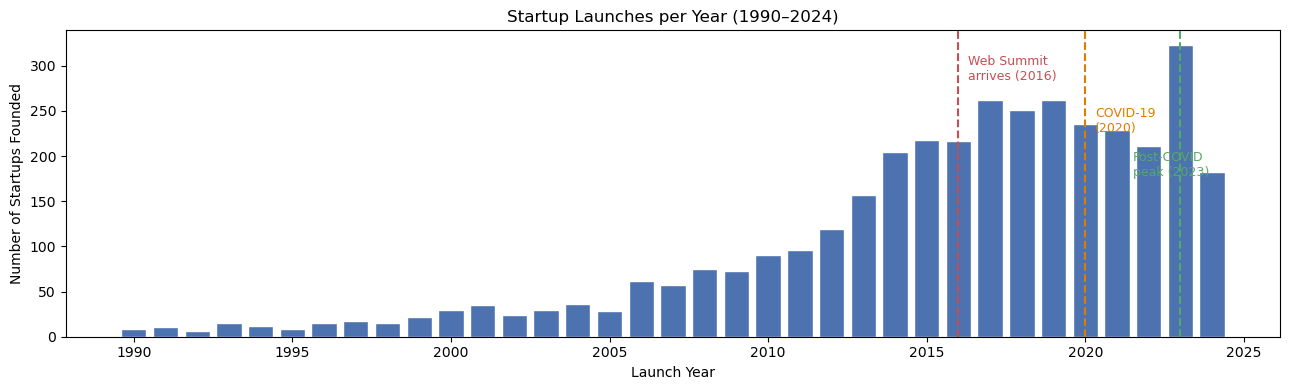

Startups founded before 1990: 130
Startups founded 1990–2009: 581
Startups founded 2010–2019: 1877
Startups founded 2020–2024: 1180


In [14]:
# Filter to 1990–2024 for the meaningful range
# 2025–2026 excluded: incomplete cohorts (year not finished) and PORDATA has also more info until 2024

df_years = df[df["Launch year"].between(1990, 2024)]

fig, ax = plt.subplots(figsize=(13, 4))

yearly = df_years["Launch year"].value_counts().sort_index()
ax.bar(yearly.index, yearly.values, color="#4C72B0", edgecolor="white", width=0.8)

# Mark key events
# Web Summit
ax.axvline(x=2016, color="#C44E52", linestyle="--", linewidth=1.5)
ax.text(2016.3, yearly.max() * 0.88, "Web Summit\narrives (2016)",
        color="#C44E52", fontsize=9)

# COVID
ax.axvline(x=2020, color="#e07b00", linestyle="--", linewidth=1.5)
ax.text(2020.3, yearly.max() * 0.70, "COVID-19\n(2020)",
        color="#e07b00", fontsize=9)

# Post-COVID recovery
ax.axvline(x=2023, color="#55A868", linestyle="--", linewidth=1.5)
ax.text(2021.5, yearly.max() * 0.55, "Post-COVID\npeak (2023)",
        color="#55A868", fontsize=9, ha="left")

ax.set_title("Startup Launches per Year (1990–2024)", fontsize=12)
ax.set_xlabel("Launch Year")
ax.set_ylabel("Number of Startups Founded")
plt.tight_layout()
plt.show()


print(f"Startups founded before 1990: {df[df['Launch year'] < 1990]['Launch year'].count()}")
print(f"Startups founded 1990–2009: {df_years[df_years['Launch year'] < 2010]['Launch year'].count()}")
print(f"Startups founded 2010–2019: {df_years[df_years['Launch year'].between(2010,2019)]['Launch year'].count()}")
print(f"Startups founded 2020–2024: {df_years[df_years['Launch year'] >= 2020]['Launch year'].count()}")

In [15]:
print(df[df["Launch year"] >= 2018]["Launch year"].value_counts().sort_index())


Launch year
2018.0    251
2019.0    262
2020.0    235
2021.0    229
2022.0    211
2023.0    323
2024.0    182
2025.0     68
2026.0      5
Name: count, dtype: int64


In [16]:
# Checking pre-1990 companies for a dive onto startup vs. other?
pre_1990 = df[df["Launch year"] < 1990][["Name", "Launch year", "HQ city", "HQ state", "Industries","Total funding (EUR M)"]]\
             .sort_values("Launch year")

print(f"Total pre-1990 startups: {len(pre_1990)}")
pre_1990

Total pre-1990 startups: 130


,Name,Launch year,HQ city,HQ state,Industries,Total funding (EUR M)
2578,CTT,1520.0,Lisbon,Lisbon,fintech,NaN
1456,Jerónimo Martins,1792.0,Lisbon,Lisbon,food,NaN
2387,Fidelidade,1808.0,Lisbon,Lisbon,fintech,NaN
153,VAA Vista Alegre Atlantis,1824.0,Ílhavo,Aveiro,marketing,NaN
48,Banco Montepio,1844.0,Lisbon,Lisbon,fintech,NaN
...,...,...,...,...,...,...
2781,Banco Empresas Montepio,1989.0,Lisbon,Lisbon,fintech,NaN
203,Guerin,1989.0,Lisbon,Lisbon,transportation,NaN
1204,Priberam,1989.0,Lisbon,Lisbon,enterprise software,0.2
107,"Miit, lda.",1989.0,Lisbon,Lisbon,media;enterprise software,0.2


In [17]:
# How many pre-1990 startups have funding data?
print(pre_1990["Total funding (EUR M)"].notna().sum(), 
      "pre-1990 companies have funding records")

# What industries do they cluster in?
print(pre_1990["Industries"].value_counts())

7 pre-1990 companies have funding records
Industries
energy                                            13
fintech                                           12
food                                              10
transportation                                     9
real estate                                        8
health                                             6
enterprise software                                5
marketing                                          4
home living                                        4
robotics                                           3
fashion                                            2
chemicals                                          2
health;wellness beauty                             2
energy;transportation                              2
semiconductors                                     2
sports                                             2
fintech;enterprise software                        1
wellness beauty                               

**Finding:** Startup formation accelerated significantly from 2010 onwards, with a notable spike around the mid-2010s coinciding with Portugal's increased visibility as a startup destination — including the relocation of Web Summit to Lisbon in 2016. The post-2020 dip could also be explained during the COVID crisis, until it peaked back around 2023.

Additionally - Regarding the older companies, after going through public companies data online, these appear actually legit infos, however, the majority of these companies don't classify as startups anymore. 
Pre-1990 entries (n = ~100) represent established corporations and legacy businesses predating Portugal's modern startup ecosystem — confirmed by inspection (e.g. CTT, founded 1520; Conduril, founded 1959). 
These are structurally different entities from the venture-backed and entrepreneurial companies this study examines. Only 7 hold funding records, so their removal does not materially affect the funding analysis. 

### District Distribution (HQ state)

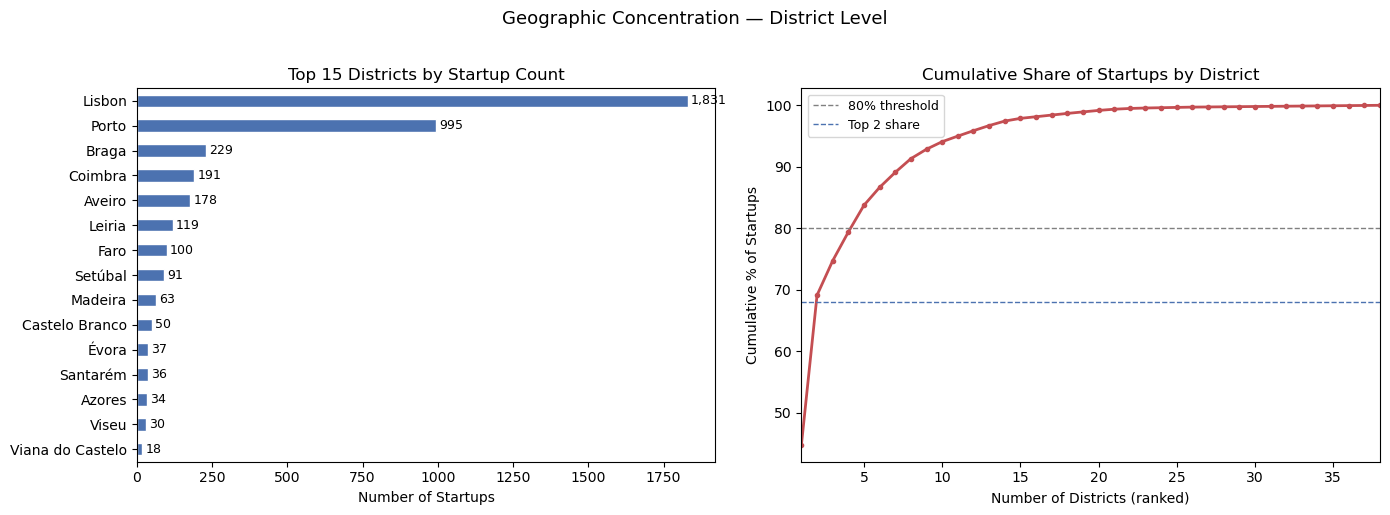

Total districts: 38
Missing HQ state: 67
Lisboa share: 44.1%
Porto share: 23.9%
Top 2 combined: 68.0%


In [18]:
# How many startups per district, and how concentrated is the distribution?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: bar chart of top 15 districts ---
district_counts = df["HQ state"].value_counts().head(15)

district_counts.plot(
    kind="barh", ax=axes[0],
    color="#4C72B0", edgecolor="white"
)
axes[0].invert_yaxis()
axes[0].set_title("Top 15 Districts by Startup Count", fontsize=12)
axes[0].set_xlabel("Number of Startups")
axes[0].set_ylabel("")

# Add count labels
for i, (val, name) in enumerate(zip(district_counts.values, district_counts.index)):
    axes[0].text(val + 10, i, f"{val:,}", va="center", fontsize=9)

# --- Right: cumulative share (concentration curve) ---
all_districts = df["HQ state"].value_counts()
cumulative_share = (all_districts.cumsum() / all_districts.sum() * 100)

axes[1].plot(
    range(1, len(cumulative_share) + 1),
    cumulative_share.values,
    color="#C44E52", linewidth=2, marker="o", markersize=3
)
axes[1].axhline(y=80, color="gray", linestyle="--", linewidth=1, label="80% threshold")
axes[1].axhline(y=68, color="#4C72B0", linestyle="--", linewidth=1, label="Top 2 share")
axes[1].set_title("Cumulative Share of Startups by District", fontsize=12)
axes[1].set_xlabel("Number of Districts (ranked)")
axes[1].set_ylabel("Cumulative % of Startups")
axes[1].legend(fontsize=9)
axes[1].set_xlim(1, len(cumulative_share))

plt.suptitle("Geographic Concentration — District Level", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print summary stats
print(f"Total districts: {df['HQ state'].nunique()}")
print(f"Missing HQ state: {df['HQ state'].isna().sum()}")
print(f"Lisboa share: {all_districts['Lisbon']/len(df)*100:.1f}%")
print(f"Porto share: {all_districts['Porto']/len(df)*100:.1f}%")
print(f"Top 2 combined: {(all_districts['Lisbon']+all_districts['Porto'])/len(df)*100:.1f}%")

**Important Finding:** The distribution is highly concentrated.
Lisbon and Porto together account for approximately 68% of all startups, with Lisbon alone holding ~44%. The cumulative curve shows that just 3 districts cover ~80% of the ecosystem — a pattern consistent with our initial assumption of strong geographic concentration.

*Note: Phase 1 plots use raw Dealroom names — "Lisbon" and "Azores" are corrected to "Lisboa" and "Açores" in Phase 2.*

### City Distribution (HQ city)

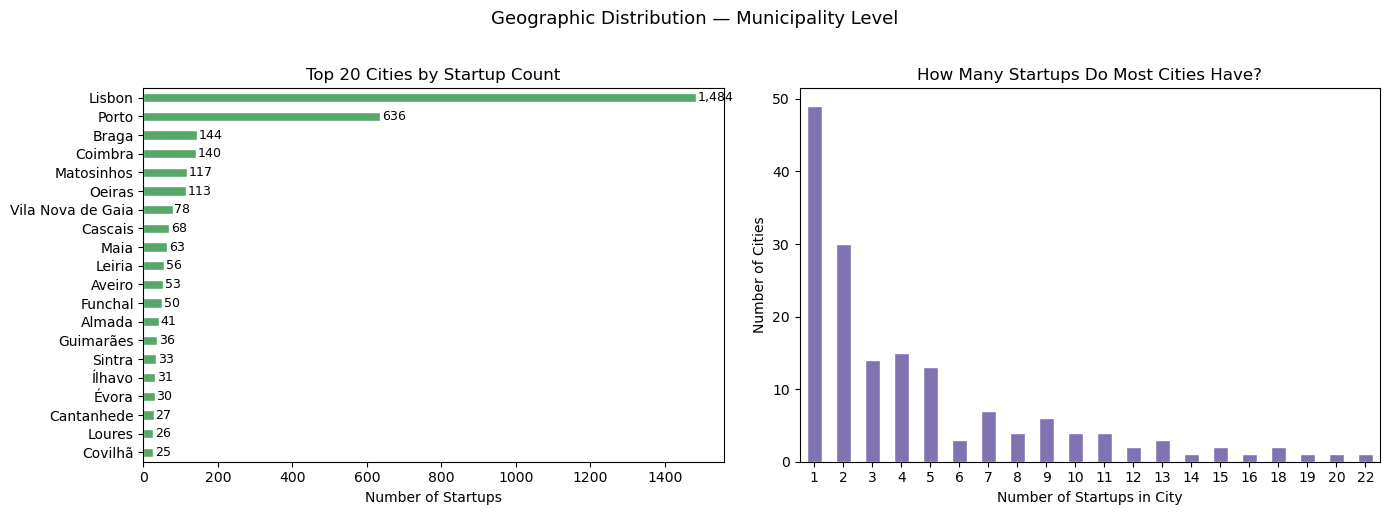

Unique cities: 41
Missing HQ city: 101
Cities with only 1 startup:49
Cities with 2–5 startups: 72
Cities with >50 startups: 11


In [19]:
# Municipality-level view — how many unique cities, and how spread is the tail?

city_counts = df["HQ city"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: top 20 cities ---
city_counts.head(20).plot(
    kind="barh", ax=axes[0],
    color="#55A868", edgecolor="white"
)
axes[0].invert_yaxis()
axes[0].set_title("Top 20 Cities by Startup Count", fontsize=12)
axes[0].set_xlabel("Number of Startups")
axes[0].set_ylabel("")

for i, val in enumerate(city_counts.head(20).values):
    axes[0].text(val + 5, i, f"{val:,}", va="center", fontsize=9)

# --- Right: distribution of city sizes (how many cities have 1, 2, 3... startups) ---
city_size_dist = city_counts.value_counts().sort_index().head(20)

city_size_dist.plot(
    kind="bar", ax=axes[1],
    color="#8172B2", edgecolor="white"
)
axes[1].set_title("How Many Startups Do Most Cities Have?", fontsize=12)
axes[1].set_xlabel("Number of Startups in City")
axes[1].set_ylabel("Number of Cities")
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Geographic Distribution — Municipality Level", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary
print(f"Unique cities: {city_counts.nunique()}")
print(f"Missing HQ city: {df['HQ city'].isna().sum()}")
print(f"Cities with only 1 startup:{(city_counts == 1).sum()}")
print(f"Cities with 2–5 startups: {((city_counts >= 2) & (city_counts <= 5)).sum()}")
print(f"Cities with >50 startups: {(city_counts > 50).sum()}")

**Finding:** The long tail is striking — 49 cities host only a single startup, and 72 cities have between 2 and 5. This means municipality-level analysis will have a small number of well-represented cities and a large sparse tail.

When merging with socioeconomic data in Phase 4, municipalities with very few startups should be interpreted cautiously.

*Note: Lisbon will be corrected to Lisboa.*

### Industry Distribution

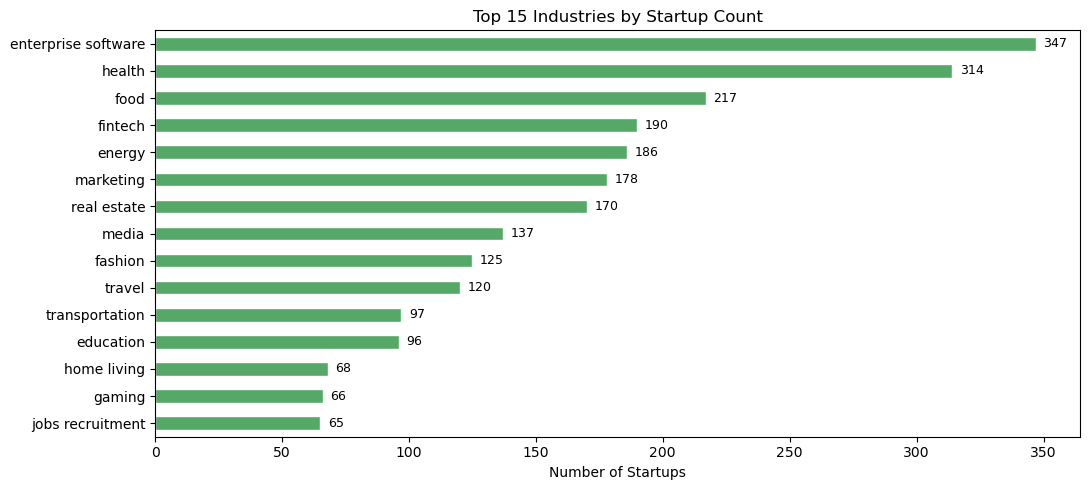

Unique industry values:    235
Missing Industries:        526
Multi-label entries (';'): 815


In [20]:
# Note: some rows have multiple industries separated by ";"
# For now we treat each cell as-is — multi-label parsing is Phase 2 work

industry_counts = df["Industries"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 5))
industry_counts.plot(kind="barh", ax=ax, color="#55A868", edgecolor="white")
ax.invert_yaxis()
ax.set_title("Top 15 Industries by Startup Count", fontsize=12)
ax.set_xlabel("Number of Startups")
ax.set_ylabel("")

for i, val in enumerate(industry_counts.values):
    ax.text(val + 3, i, f"{val:,}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"Unique industry values:    {df['Industries'].nunique()}")
print(f"Missing Industries:        {df['Industries'].isna().sum()}")
print(f"Multi-label entries (';'): {df['Industries'].str.contains(';', na=False).sum()}")

**Finding:** Enterprise software, health, and food dominate the ecosystem. A meaningful share of entries contain multiple industry labels (separated by `;`), which will require handling in Phase 2. Missing values (n=526) are noted but do not critically affect sector-level analysis given the overall volume.

### Funding & Company Status

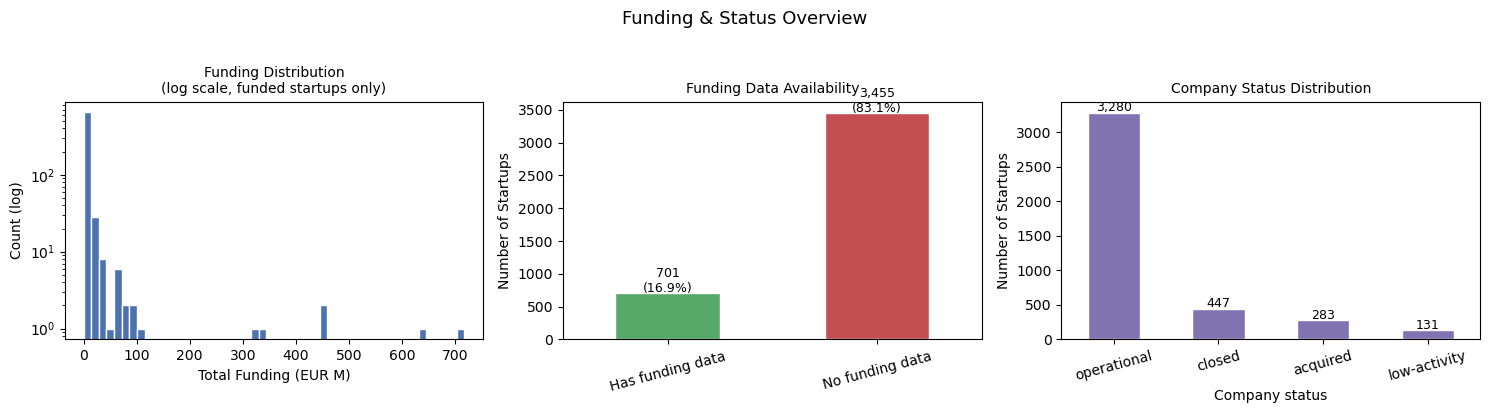

Median funding (funded only): EUR 0.60M
Mean funding (funded only):   EUR 8.16M  ← skewed by outliers
Max funding:                  EUR 716.82M


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1st chart: funding distribution (log scale, funded only)
funded = df["Total funding (EUR M)"].dropna()
axes[0].hist(funded, bins=50, color="#4C72B0", edgecolor="white", log=True)
axes[0].set_title("Funding Distribution\n(log scale, funded startups only)", fontsize=10)
axes[0].set_xlabel("Total Funding (EUR M)")
axes[0].set_ylabel("Count (log)")

# 2nd chart: funded vs unfunded
funding_status = pd.Series({
    "Has funding data": df["Total funding (EUR M)"].notna().sum(),
    "No funding data":  df["Total funding (EUR M)"].isna().sum()
})
funding_status.plot(kind="bar", ax=axes[1], color=["#55A868", "#C44E52"], edgecolor="white")
axes[1].set_title("Funding Data Availability", fontsize=10)
axes[1].set_ylabel("Number of Startups")
axes[1].tick_params(axis="x", rotation=15)
for i, val in enumerate(funding_status.values):
    axes[1].text(i, val + 20, f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=9)

# 3rd chart: company status 
status_counts = df["Company status"].value_counts()
status_counts.plot(kind="bar", ax=axes[2], color="#8172B2", edgecolor="white")
axes[2].set_title("Company Status Distribution", fontsize=10)
axes[2].set_ylabel("Number of Startups")
axes[2].tick_params(axis="x", rotation=15)
for i, val in enumerate(status_counts.values):
    axes[2].text(i, val + 20, f"{val:,}", ha="center", fontsize=9)

plt.suptitle("Funding & Status Overview", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Median funding (funded only): EUR {funded.median():.2f}M")
print(f"Mean funding (funded only):   EUR {funded.mean():.2f}M  ← skewed by outliers")
print(f"Max funding:                  EUR {funded.max():.2f}M")

**Finding:** 83% of startups have no funding record — a structural finding, not merely a data quality issue. This suggests the vast majority of Portuguese startups are bootstrapped or rely on non-VC capital. 
Among those with funding, the distribution is heavily right-skewed (median ~EUR 0.6M vs mean ~EUR 8M), driven by a small number of highly funded outliers. The median is the appropriate measure for geographic comparisons.

79% of startups are operational. Of the remaining 21%: 10.8% are closed, 6.8% acquired, and 3.2% low-activity. 
The combined non-operational rate of 21% is worth contextualising — acquired startups represent ecosystem exits, while closed and low-activity entries suggest natural attrition. The low-activity category is worth noting as a potential data quality signal - these may be companies Dealroom has not been able to verify as still operating.

### Employees Range

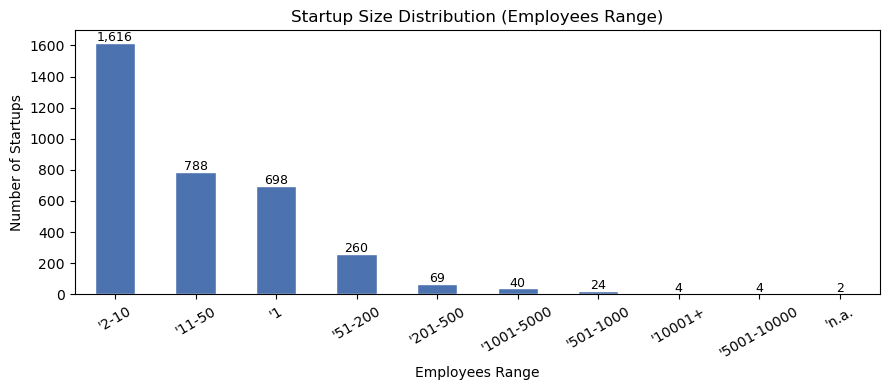

Raw values (note the leading apostrophe):
["'2-10", "'11-50", "'1", "'51-200", "'201-500", "'1001-5000", "'501-1000", "'10001+", "'5001-10000", "'n.a."]


In [22]:
emp_counts = df["Employees Range"].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
emp_counts.plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Startup Size Distribution (Employees Range)", fontsize=12)
ax.set_xlabel("Employees Range")
ax.set_ylabel("Number of Startups")
ax.tick_params(axis="x", rotation=30)

for i, val in enumerate(emp_counts.values):
    ax.text(i, val + 10, f"{val:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# Confirm the apostrophe issue before fixing it in Phase 2
print("Raw values (note the leading apostrophe):")
print(emp_counts.index.tolist())

**Finding:** The ecosystem is dominated by micro and small startups — the majority fall in the 1–10 and 11–50 employee ranges, confirming
the early-stage nature of most entries. 
The leading apostrophe artifact (`'2-10` instead of `2-10`) is visible in raw values and will be corrected in Phase 2.

### Audit Summary & Phase 2 Decisions

Based on the exploration above, here's the suggestion for next steps: 

#### Scope Decisions

| Decision | Justification |
|---|---|
| Filter to Portugal only (n=4,107) | 98.8% of entries are Portuguese HQs. 49 foreign entries are out of scope for a domestic geographic study. A subset may represent Portuguese-founded companies that relocated abroad — acknowledged as a limitation. |
| Filter Launch year 1990 - 2024 | Pre-1990 entries are legacy corporations, not startups (e.g. CTT founded 1520, Conduril 1959). Only 7 hold funding records. Portugal's modern startup ecosystem is a post-EU accession phenomenon. |

#### Column Decisions

| Column | Decision | Justification |
|---|---|---|
| `HQ region` | Drop | Always "Europe" — zero variance |
| `HQ country` | Filter then drop | Used to scope dataset, no further analytical value |
| `HQ state` | Keep | Primary district-level geographic key |
| `HQ city` | Keep | Primary municipality-level geographic key |
| `Custom HQ regions` | Parse then drop | Extract Lisbon Metro / Porto Metro flag, then discard |
| `Founding location` | Drop | 96.6% missing — `HQ city` is the reliable location signal |
| `Total funding (EUR M)` | Keep with caution | 83% missing is a structural finding — most startups are unbacked by VC. Median (EUR 0.6M) used for comparisons, not mean (EUR 8.16M) |
| `Launch year` | Keep — filter applied | See scope decisions above |
| `Launch month` | Drop | 68% missing — year-level granularity is sufficient |
| `Industries` | Keep — parse in Phase 2 | 815 multi-label entries (`;` separated) require splitting. 526 missing noted. |
| `Sub industries` | Drop | 62% missing, redundant with `Industries` |
| `Employees Range` | Keep — fix prefix | Leading `'` artifact (e.g. `'2-10` → `2-10`) corrected in Phase 2 |
| `Each round type` | Parse then drop | Extract `has_grant` and `has_vc` binary flags before dropping |
| `Each round amount` | Drop | `Total funding (EUR M)` already aggregates this |
| `Each round currency` | Drop | Not needed at startup level |
| `Each round date` | Drop | Round timeline analysis is out of scope |
| `Each round investors` | Drop | Out of scope for this phase |
| `Company status` | Keep | Operational vs. closed vs. acquired adds analytical depth |

#### Missing Value Strategy

| Column | Missing (%) | Treatment |
|---|---|---|
| `Total funding (EUR M)` | 83.0% | Keep NaNs — treated as "unfunded". Create `has_funding` binary flag |
| `Industries` | 12.7% | Keep rows — missing industry does not disqualify a startup from geographic analysis |
| `HQ city` | 2.4% | Flag and exclude from municipality-level analysis only |
| `HQ state` | 1.6% | Flag and exclude from district-level analysis only |
| `Launch year` | 7.6% | Exclude from temporal analysis only — keep for geographic counts |

#### Features to Engineer in Phase 2

| Feature | Definition | Purpose |
|---|---|---|
| `has_funding` | 1 if `Total funding (EUR M)` is not null | Funded vs. bootstrapped split |
| `has_grant` | 1 if any round type contains GRANT or SUPPORT PROGRAM | Public funding flag |
| `has_vc` | 1 if any round type contains SEED, EARLY VC, SERIES A/B/C | VC-backed flag |
| `startup_age` | 2025 − `Launch year` | Ecosystem maturity proxy |
| `primary_industry` | First value before `;` in `Industries` | Clean single-label for aggregation |
| `metro_area` | Extracted from `Custom HQ regions` | Lisbon Metro / Porto Metro / Other |

#### Known Limitations

- 49 foreign-HQ companies excluded — may include Portuguese-founded startups that internationalised
- 83% missing funding data limits financial analysis to a non-representative subset
- `HQ city` values will require fuzzy matching against INE municipality names before merging with socioeconomic data (Phase 3)
- Dealroom coverage is not exhaustive — smaller or informal startups may be systematically underrepresented outside Lisbon and Porto, which could amplify the concentration finding artificially

# Phase 2 - Clean & Transform

In [23]:
df_clean = df.copy()

## 2.1 Filter scoping

In [24]:
# Step 1: Filter to Portugal only
before = len(df_clean)
df_clean = df_clean[df_clean["HQ country"] == "Portugal"]
print(f"After Portugal filter:     {len(df_clean):,} rows (removed {before - len(df_clean)})")

# Step 2: Filter Launch year — keep 1990–2024, and rows where year is missing
# We keep missing Launch year rows because they're still valid for geographic analysis
before = len(df_clean)
df_clean = df_clean[
    df_clean["Launch year"].isna() |
    df_clean["Launch year"].between(1990, 2024)
]
print(f"After Launch year filter:  {len(df_clean):,} rows (removed {before - len(df_clean)})")
print(f"\nFinal scoped dataset:      {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")

# Reset index cleanly after filtering
df_clean = df_clean.reset_index(drop=True)
print(f"Index reset:               0 to {len(df_clean)-1}")

After Portugal filter:     4,107 rows (removed 49)
After Launch year filter:  3,904 rows (removed 203)

Final scoped dataset:      3,904 rows × 19 columns
Index reset:               0 to 3903


Dataset scoped to Portuguese startups founded 1990–2024.
Rows with missing Launch year are retained — they remain valid for geographic analysis.

## 2.2 Fix Quality Issues 


In [25]:
# Applied decisions:
#   - Drop zero-variance and low-signal columns
#   - Strip leading apostrophe from Employees Range
#   - Flag missing HQ city and HQ state

# --- Drop columns ---
cols_to_drop = [
    "HQ region",          # always "Europe" — zero variance
    "HQ country",         # always "Portugal" after filter — zero variance
    "Founding location",  # 96.6% missing — unreliable
    "Launch month",       # 68% missing — year granularity is sufficient
    "Sub industries",     # 62% missing — redundant with Industries
    "Each round amount",  # aggregated in Total funding already
    "Each round currency",# not needed at startup level
    "Each round date",    # round timeline out of scope
    "Each round investors"# out of scope
]

df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Columns after drop: {df_clean.shape[1]} (removed {len(cols_to_drop)})")
print(f"Remaining: {list(df_clean.columns)}")

# --- Fix Employees Range apostrophe artifact ---
# Raw values like '2-10 should be 2-10
df_clean["Employees Range"] = df_clean["Employees Range"].str.lstrip("'")

print(f"\nEmployees Range values after fix:")
print(df_clean["Employees Range"].value_counts())

# --- Flag missing HQ city and HQ state ---
# These rows can't participate in geographic analysis but are valid otherwise
df_clean["hq_city_missing"] = df_clean["HQ city"].isna().astype(int)
df_clean["hq_state_missing"] = df_clean["HQ state"].isna().astype(int)

print(f"\nRows missing HQ city:  {df_clean['hq_city_missing'].sum()}")
print(f"Rows missing HQ state: {df_clean['hq_state_missing'].sum()}")

Columns after drop: 10 (removed 9)
Remaining: ['Name', 'HQ state', 'HQ city', 'Custom HQ regions', 'Total funding (EUR M)', 'Launch year', 'Industries', 'Employees Range', 'Each round type', 'Company status']

Employees Range values after fix:
Employees Range
2-10         1554
11-50         742
1             686
51-200        220
201-500        48
1001-5000      15
501-1000       14
n.a.            2
Name: count, dtype: int64

Rows missing HQ city:  91
Rows missing HQ state: 57


In [26]:
# All corrections applied to df_clean before aggregation
# Ensures aggregated DataFrames are built on clean INE-standard names

city_corrections = {
    "Lisbon": "Lisboa",   # English → Portuguese INE standard
}

state_corrections = {
    "Lisbon": "Lisboa",   # English → Portuguese INE standard
    "Azores": "Açores",   # English → Portuguese INE standard
}

# Apply city corrections
df_clean["HQ city"] = df_clean["HQ city"].str.strip().replace(city_corrections)

# Apply state corrections
df_clean["HQ state"] = df_clean["HQ state"].replace(state_corrections)

# Verify
print("─── HQ city ───")
print(f"'Lisbon' remaining:  {(df_clean['HQ city'] == 'Lisbon').sum()}")
print(f"'Lisboa' count:      {(df_clean['HQ city'] == 'Lisboa').sum()}")

print("\n─── HQ state ───")
print(f"'Lisbon' remaining:  {(df_clean['HQ state'] == 'Lisbon').sum()}")
print(f"'Azores' remaining:  {(df_clean['HQ state'] == 'Azores').sum()}")
print(f"'Lisboa' count:      {(df_clean['HQ state'] == 'Lisboa').sum()}")
print(f"'Açores' count:      {(df_clean['HQ state'] == 'Açores').sum()}")
print()
print("All HQ state values after correction:")
print(sorted(df_clean["HQ state"].dropna().unique()))

─── HQ city ───
'Lisbon' remaining:  0
'Lisboa' count:      1417

─── HQ state ───
'Lisbon' remaining:  0
'Azores' remaining:  0
'Lisboa' count:      1731
'Açores' count:      34

All HQ state values after correction:
['Aveiro', 'Açores', 'Beja', 'Braga', 'Bragança', 'Castelo Branco', 'Coimbra', 'Faro', 'Guarda', 'Leiria', 'Lisboa', 'Madeira', 'Portalegre', 'Porto', 'Santarém', 'Setúbal', 'Viana do Castelo', 'Vila Real', 'Viseu', 'Évora']


**Findings:** 
- **9 columns dropped** — zero-variance, high-missingness, or out-of-scope (see audit summary)
- **Apostrophe artifact fixed** — `Employees Range` values corrected (e.g. `'2-10` → `2-10`)
- **Missing geographic flags created** — `hq_city_missing` and `hq_state_missing` binary flags
- **City name standardised** — `Lisbon` → `Lisboa` (INE Portuguese standard)
- **District names standardised** — `Lisbon` → `Lisboa`, `Azores` → `Açores` (INE Portuguese standard)

## 2.3 Parse & Extract Features


In [27]:
# Three extractions:
#   - primary_industry: first label before ";" in Industries
#   - metro_area: extracted from Custom HQ regions
#   - has_grant / has_vc: extracted from Each round type, then column dropped

# --- primary_industry ---
# Industries contains multi-label values like "health;enterprise software"
# We take only the first label as the primary classification
df_clean["primary_industry"] = (
    df_clean["Industries"]
    .str.split(";")
    .str[0]
    .str.strip()
    .str.lower()
)

print("Primary industry distribution (top 10):")
print(df_clean["primary_industry"].value_counts().head(10))

# --- metro_area ---
# Custom HQ regions contains tags like "Lisbon Metropolitan Area" or "Porto Metropolitan Area"
# We extract a clean categorical flag from this
def extract_metro(value):
    if pd.isna(value):
        return "Other"
    if "Lisbon Metropolitan Area" in value:
        return "Lisboa Metro"    
    if "Porto Metropolitan Area" in value:
        return "Porto Metro"   
    return "Other"

df_clean["metro_area"] = df_clean["Custom HQ regions"].apply(extract_metro)

print(f"\nMetro area distribution:")
print(df_clean["metro_area"].value_counts())

# --- has_grant / has_vc ---
# Extracted from Each round type before dropping the column
def has_round_type(value, keywords):
    """Check if any round type in a semicolon-delimited string matches keywords."""
    if pd.isna(value):
        return 0
    rounds = [r.strip().upper() for r in value.split(";")]
    return int(any(k in rounds for k in keywords))

grant_keywords = ["GRANT", "SUPPORT PROGRAM"]
vc_keywords    = ["SEED", "EARLY VC", "SERIES A", "SERIES B", "SERIES C"]

df_clean["has_grant"] = df_clean["Each round type"].apply(
    lambda x: has_round_type(x, grant_keywords)
)
df_clean["has_vc"] = df_clean["Each round type"].apply(
    lambda x: has_round_type(x, vc_keywords)
)

print(f"\nStartups with grant/support:  {df_clean['has_grant'].sum():,}")
print(f"Startups with VC backing:     {df_clean['has_vc'].sum():,}")

# Now drop Each round type — extraction complete
df_clean = df_clean.drop(columns=["Each round type", "Custom HQ regions"])
print(f"\nColumns after extraction: {df_clean.shape[1]}")

Primary industry distribution (top 10):
primary_industry
health                 404
enterprise software    326
food                   257
fintech                246
energy                 218
marketing              209
media                  196
real estate            190
travel                 175
fashion                151
Name: count, dtype: int64

Metro area distribution:
metro_area
Lisboa Metro    1758
Other           1145
Porto Metro     1001
Name: count, dtype: int64

Startups with grant/support:  437
Startups with VC backing:     679

Columns after extraction: 14


Three features extracted:
- `primary_industry` — first industry label, cleaned and lowercased
- `metro_area` — Lisbon Metro / Porto Metro / Other, from Custom HQ regions
- `has_grant` / `has_vc` — binary flags from round type data

`Each round type` and `Custom HQ regions` dropped after extraction.

## 2.4 - Feature engineering

In [28]:
# Two derived features:
#   - has_funding: binary flag for whether Total funding is available
#   - startup_age: years since founding (proxy for ecosystem maturity)

# --- has_funding ---
df_clean["has_funding"] = df_clean["Total funding (EUR M)"].notna().astype(int)

print(f"Funded startups:   {df_clean['has_funding'].sum():,} ({df_clean['has_funding'].mean()*100:.1f}%)")
print(f"Unfunded startups: {(df_clean['has_funding']==0).sum():,} ({(df_clean['has_funding']==0).mean()*100:.1f}%)")

# --- startup_age ---
# Based on 2025 as reference year — consistent with project timeline
# Rows with missing Launch year will have NaN age — expected and acceptable
df_clean["startup_age"] = 2025 - df_clean["Launch year"]

print(f"\nStartup age summary:")
print(df_clean["startup_age"].describe().round(1))

Funded startups:   656 (16.8%)
Unfunded startups: 3,248 (83.2%)

Startup age summary:
count    3589.0
mean        9.4
std         6.8
min         1.0
25%         4.0
50%         8.0
75%        12.0
max        35.0
Name: startup_age, dtype: float64


Two features engineered:
- `has_funding` — 1 if Total funding is available, 0 otherwise
- `startup_age` — years since founding relative to 2025

Rows with missing Launch year carry NaN startup_age — valid for geographic analysis.

In [29]:
df_clean

,Name,HQ state,HQ city,Total funding (EUR M),Launch year,Industries,Employees Range,Company status,hq_city_missing,hq_state_missing,primary_industry,metro_area,has_grant,has_vc,has_funding,startup_age
0,RDfine,Coimbra,Coimbra,NaN,2023.0,health,2-10,operational,0,0,health,Other,0,0,0,2.0
1,BackChain,Porto,Porto,NaN,2018.0,security,2-10,operational,0,0,security,Porto Metro,0,0,0,7.0
2,Liveplace,Guarda,Sabugal,NaN,1996.0,real estate,51-200,acquired,0,0,real estate,Other,0,0,0,29.0
3,Inspiring,Lisboa,Lisboa,NaN,2010.0,marketing,11-50,operational,0,0,marketing,Lisboa Metro,0,0,0,15.0
4,Events by tlc,Lisboa,Lisboa,NaN,2002.0,event tech,2-10,operational,0,0,event tech,Lisboa Metro,0,0,0,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3899,SF SYSTEM,Madeira,NaN,NaN,2022.0,enterprise software,11-50,operational,1,0,enterprise software,Other,0,0,0,3.0
3900,See Health,Madeira,Funchal,NaN,2020.0,health;enterprise software,1,operational,0,0,health,Other,0,0,0,5.0
3901,Missing Link,Coimbra,Coimbra,NaN,2020.0,NaN,2-10,operational,0,0,NaN,Other,0,0,0,5.0
3902,thecodex.world,Lisboa,Lisboa,NaN,2023.0,sports,2-10,operational,0,0,sports,Lisboa Metro,0,0,0,2.0


In [30]:
df_clean.isna().sum()

Name                        0
HQ state                   57
HQ city                    91
Total funding (EUR M)    3248
Launch year               315
Industries                503
Employees Range           623
Company status             15
hq_city_missing             0
hq_state_missing            0
primary_industry          503
metro_area                  0
has_grant                   0
has_vc                      0
has_funding                 0
startup_age               315
dtype: int64

Dropping rows with missing values is only justified when the missingness itself disqualifies the row from all analyses. That is not the case here.



City and district names corrected to INE Portuguese standard before aggregation — ensures all outputs use consistent naming.

## Phase 3 - Aggregation 

## 3.1 - Group by municipality

In [31]:
# Unit: HQ city — excludes 91 rows with missing HQ city

df_geo = df_clean[df_clean["hq_city_missing"] == 0].copy()

df_municipality = df_geo.groupby(["HQ city", "HQ state"]).agg(

    # --- Volume ---
    startup_count       = ("Name", "count"),
    funded_count        = ("has_funding", "sum"),
    grant_count         = ("has_grant", "sum"),
    vc_count            = ("has_vc", "sum"),

    # --- Funding ---
    total_funding_eur_m  = ("Total funding (EUR M)", "sum"),
    median_funding_eur_m = ("Total funding (EUR M)", "median"),

    # --- Ecosystem maturity ---
    avg_startup_age      = ("startup_age", "mean"),

    # --- Sector diversity ---
    sector_diversity     = ("primary_industry", "nunique"),
    top_industry         = ("primary_industry", lambda x: x.value_counts().idxmax()
                            if x.notna().any() else None),

    # --- Size profile ---
    pct_operational      = ("Company status",
                            lambda x: (x == "operational").sum() / len(x) * 100),
    pct_closed           = ("Company status",
                            lambda x: (x == "closed").sum() / len(x) * 100),

    # --- Metro flag (take most common value per city) ---
    metro_area           = ("metro_area", lambda x: x.value_counts().idxmax()),

).reset_index()

# --- Derived ratios ---
df_municipality["funded_ratio"]   = (
    df_municipality["funded_count"] / df_municipality["startup_count"] * 100
).round(1)

df_municipality["grant_ratio"]    = (
    df_municipality["grant_count"] / df_municipality["startup_count"] * 100
).round(1)

df_municipality["vc_ratio"]       = (
    df_municipality["vc_count"] / df_municipality["startup_count"] * 100
).round(1)

# --- Round numeric columns ---
df_municipality["total_funding_eur_m"]  = df_municipality["total_funding_eur_m"].round(2)
df_municipality["median_funding_eur_m"] = df_municipality["median_funding_eur_m"].round(2)
df_municipality["avg_startup_age"]      = df_municipality["avg_startup_age"].round(1)
df_municipality["pct_operational"]      = df_municipality["pct_operational"].round(1)
df_municipality["pct_closed"]           = df_municipality["pct_closed"].round(1)

print(f"Municipalities in dataset:  {len(df_municipality)}")
print(f"Columns:                    {list(df_municipality.columns)}")
print(df_municipality.sort_values("startup_count", ascending=False).head(10))

Municipalities in dataset:  164
Columns:                    ['HQ city', 'HQ state', 'startup_count', 'funded_count', 'grant_count', 'vc_count', 'total_funding_eur_m', 'median_funding_eur_m', 'avg_startup_age', 'sector_diversity', 'top_industry', 'pct_operational', 'pct_closed', 'metro_area', 'funded_ratio', 'grant_ratio', 'vc_ratio']
               HQ city HQ state  startup_count  funded_count  grant_count  \
62              Lisboa   Lisboa           1417           245          145   
111              Porto    Porto            619            88           56   
26               Braga    Braga            138            37           21   
38             Coimbra  Coimbra            137            37           37   
73          Matosinhos    Porto            113            23           14   
87              Oeiras   Lisboa            102            22            9   
152  Vila Nova de Gaia    Porto             75             5            0   
33             Cascais   Lisboa             64  

Municipality-level aggregation produced.
91 startups with missing HQ city excluded from this aggregation only.

Key metrics: startup count, funding, sector diversity, size profile, metro flag.

## 3.2 - Group by district


In [32]:
# Unit: HQ state — excludes 57 rows with missing HQ state

df_geo_state = df_clean[df_clean["hq_state_missing"] == 0].copy()

df_district = df_geo_state.groupby("HQ state").agg(

    startup_count        = ("Name", "count"),
    funded_count         = ("has_funding", "sum"),
    grant_count          = ("has_grant", "sum"),
    vc_count             = ("has_vc", "sum"),
    total_funding_eur_m  = ("Total funding (EUR M)", "sum"),
    median_funding_eur_m = ("Total funding (EUR M)", "median"),
    avg_startup_age      = ("startup_age", "mean"),
    sector_diversity     = ("primary_industry", "nunique"),
    top_industry         = ("primary_industry", lambda x: x.value_counts().idxmax()
                            if x.notna().any() else None),
    pct_operational      = ("Company status",
                            lambda x: (x == "operational").sum() / len(x) * 100),
    pct_closed           = ("Company status",
                            lambda x: (x == "closed").sum() / len(x) * 100),

).reset_index()

# --- Derived ratios ---
df_district["funded_ratio"] = (
    df_district["funded_count"] / df_district["startup_count"] * 100
).round(1)

df_district["grant_ratio"]  = (
    df_district["grant_count"] / df_district["startup_count"] * 100
).round(1)

df_district["vc_ratio"]     = (
    df_district["vc_count"] / df_district["startup_count"] * 100
).round(1)

# --- Round numeric columns ---
df_district["total_funding_eur_m"]  = df_district["total_funding_eur_m"].round(2)
df_district["median_funding_eur_m"] = df_district["median_funding_eur_m"].round(2)
df_district["avg_startup_age"]      = df_district["avg_startup_age"].round(1)
df_district["pct_operational"]      = df_district["pct_operational"].round(1)
df_district["pct_closed"]           = df_district["pct_closed"].round(1)

print(f"Districts in dataset:  {len(df_district)}")
print(f"Columns:               {list(df_district.columns)}")
print()
print(df_district.sort_values("startup_count", ascending=False))

Districts in dataset:  20
Columns:               ['HQ state', 'startup_count', 'funded_count', 'grant_count', 'vc_count', 'total_funding_eur_m', 'median_funding_eur_m', 'avg_startup_age', 'sector_diversity', 'top_industry', 'pct_operational', 'pct_closed', 'funded_ratio', 'grant_ratio', 'vc_ratio']

            HQ state  startup_count  funded_count  grant_count  vc_count  \
10            Lisboa           1731           302          186       333   
13             Porto            959           131           78       141   
3              Braga            219            49           31        53   
6            Coimbra            187            47           48        48   
0             Aveiro            160            25           24        18   
9             Leiria            110            17           11        15   
7               Faro             96            12            8        10   
15           Setúbal             89            12            7         8   
11           Ma

District-level aggregation produced.
57 startups with missing HQ state excluded from this aggregation only.
District aggregation mirrors municipality metrics for consistency across levels.

In [33]:
# Check current unique city and state values
print("Current unique HQ city values:")
print(sorted(df_clean["HQ city"].dropna().unique()))
print()
print("Current unique HQ state values:")
print(sorted(df_clean["HQ state"].dropna().unique()))

Current unique HQ city values:
['Abrantes', 'Albufeira', 'Alcanena', 'Alcobaça', 'Alcácer do Sal', 'Alenquer', 'Aljustrel', 'Almada', 'Alvaiázere', 'Amadora', 'Amarante', 'Amares', 'Anadia', 'Angra do Heroísmo', 'Ansião', 'Arcos de Valdevez', 'Arouca', 'Arraiolos', 'Arruda dos Vinhos', 'Aveiro', 'Azambuja', 'Barcelos', 'Barreiro', 'Batalha', 'Beja', 'Benavente', 'Braga', 'Bragança', 'Cabeceiras de Basto', 'Cadaval', 'Caldas da Rainha', 'Cantanhede', 'Cartaxo', 'Cascais', 'Castelo Branco', 'Castro Daire', 'Castro Marim', 'Chaves', 'Coimbra', 'Constância', 'Covilhã', 'Câmara de Lobos', 'Espinho', 'Esposende', 'Estarreja', 'Estremoz', 'Fafe', 'Faro', 'Felgueiras', 'Figueira da Foz', 'Figueiró dos Vinhos', 'Funchal', 'Fundão', 'Gondomar', 'Guarda', 'Guimarães', 'Horta', 'Lagoa', 'Lagos', 'Lamego', 'Leiria', 'Lisboa', 'Loulé', 'Loures', 'Lourinhã', 'Lousada', 'Machico', 'Mafra', 'Maia', 'Mangualde', 'Marco de Canaveses', 'Marinha Grande', 'Matosinhos', 'Mação', 'Mirandela', 'Moita', 'Monchi

### Some takeaways from phase 3

Coimbra's grant ratio (25.7%) exceeds its funded ratio (25.1%) — meaning some startups have grants but no recorded total funding. University-driven public funding at work.

Guarda has a median funding of EUR 10.57M — suspiciously high for 11 startups. That's one large outlier inflating the median. Worth flagging as a limitation in the handoff note.

Vila Real has a 40% funded ratio — highest of any district with meaningful volume. Unexpected overperformer.

There are 20 districts because Açores and Madeira are treated as single district-level units rather than broken into individual municipalities. This is consistent with how Dealroom tags them in the source data.

## Phase 4

### 4.1 - Save clean startup CSV

In [34]:
# Three outputs exported as UTF-8 encoded CSVs
# utf-8-sig encoding ensures Portuguese accented characters render correctly in Excel and other tools teammates may use

# --- Startup-level clean dataset ---
df_clean.to_csv("startups_clean.csv", index=False, encoding="utf-8-sig")
print(f" startups_clean.csv")
print(f"  {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")

# --- Municipality-level aggregation ---
df_municipality.to_csv("startups_by_municipality.csv", index=False, encoding="utf-8-sig")
print(f"\n startups_by_municipality.csv")
print(f"  {df_municipality.shape[0]} rows × {df_municipality.shape[1]} columns")

# --- District-level aggregation ---
df_district.to_csv("startups_by_district.csv", index=False, encoding="utf-8-sig")
print(f"\n startups_by_district.csv")
print(f"  {df_district.shape[0]} rows × {df_district.shape[1]} columns")

print("\nAll files exported successfully.")

 startups_clean.csv
  3,904 rows × 16 columns

 startups_by_municipality.csv
  164 rows × 17 columns

 startups_by_district.csv
  20 rows × 15 columns

All files exported successfully.


### 4.2 - Document schema

In [35]:
# Confirm outputs are complete and consistent before handoff

print("─── startups_clean.csv ───")
print(f"Columns: {list(df_clean.columns)}")
print(f"Missing hq_city_missing=0: {(df_clean['hq_city_missing']==0).sum():,} rows available for municipality analysis")
print(f"Missing hq_state_missing=0: {(df_clean['hq_state_missing']==0).sum():,} rows available for district analysis")

print("\n─── startups_by_municipality.csv ───")
print(f"Columns: {list(df_municipality.columns)}")
print(f"Top 5 municipalities:\n{df_municipality.nlargest(5, 'startup_count')[['HQ city','HQ state','startup_count','funded_ratio','grant_ratio']].to_string(index=False)}")

print("\n─── startups_by_district.csv ───")
print(f"Columns: {list(df_district.columns)}")
print(f"Top 5 districts:\n{df_district.nlargest(5, 'startup_count')[['HQ state','startup_count','funded_ratio','grant_ratio']].to_string(index=False)}")

─── startups_clean.csv ───
Columns: ['Name', 'HQ state', 'HQ city', 'Total funding (EUR M)', 'Launch year', 'Industries', 'Employees Range', 'Company status', 'hq_city_missing', 'hq_state_missing', 'primary_industry', 'metro_area', 'has_grant', 'has_vc', 'has_funding', 'startup_age']
Missing hq_city_missing=0: 3,813 rows available for municipality analysis
Missing hq_state_missing=0: 3,847 rows available for district analysis

─── startups_by_municipality.csv ───
Columns: ['HQ city', 'HQ state', 'startup_count', 'funded_count', 'grant_count', 'vc_count', 'total_funding_eur_m', 'median_funding_eur_m', 'avg_startup_age', 'sector_diversity', 'top_industry', 'pct_operational', 'pct_closed', 'metro_area', 'funded_ratio', 'grant_ratio', 'vc_ratio']
Top 5 municipalities:
   HQ city HQ state  startup_count  funded_ratio  grant_ratio
    Lisboa   Lisboa           1417          17.3         10.2
     Porto    Porto            619          14.2          9.0
     Braga    Braga            138     

## Handoff Note

**Output files:** `startups_clean.csv`, `startups_by_municipality.csv`, `startups_by_district.csv`

---

### File Schemas

**`startups_clean.csv`** — one row per startup (4,000~ rows post-cleaning)

| Column | Type | Notes |
|---|---|---|
| `Name` | string | Startup name |
| `HQ state` | string | District — INE Portuguese standard |
| `HQ city` | string | Municipality — INE Portuguese standard |
| `Total funding (EUR M)` | float | 83% missing — use `has_funding` flag |
| `Launch year` | float | 1990–2024 only |
| `Industries` | string | May contain `;` separated multi-labels |
| `Employees Range` | string | Cleaned — apostrophe artifact removed |
| `Company status` | string | operational / closed / acquired |
| `hq_city_missing` | int | 1 if HQ city is missing |
| `hq_state_missing` | int | 1 if HQ state is missing |
| `primary_industry` | string | First industry label — clean single value |
| `metro_area` | string | Lisboa Metro / Porto Metro / Other |
| `has_grant` | int | 1 if any round type = GRANT or SUPPORT PROGRAM |
| `has_vc` | int | 1 if any round type = SEED, EARLY VC, SERIES A/B/C |
| `has_funding` | int | 1 if Total funding is not null |
| `startup_age` | float | 2025 − Launch year |

**`startups_by_municipality.csv`** — one row per HQ city (164 municipalities)

| Column | Notes |
|---|---|
| `startup_count` | Total startups in municipality |
| `funded_count` | Startups with any funding record |
| `grant_count` | Startups with grant or support program |
| `vc_count` | Startups with VC backing |
| `total_funding_eur_m` | Sum of Total funding |
| `median_funding_eur_m` | Median funding — use instead of mean (outliers) |
| `avg_startup_age` | Mean years since founding |
| `sector_diversity` | Number of distinct primary industries |
| `top_industry` | Most common primary industry |
| `pct_operational` / `pct_closed` | % by company status |
| `metro_area` | Lisboa Metro / Porto Metro / Other |
| `funded_ratio` | % of startups with funding |
| `grant_ratio` | % of startups with grants |
| `vc_ratio` | % of startups with VC |

**`startups_by_district.csv`** — one row per HQ state (20 districts)
Same columns as municipality level — use for district choropleth or as fallback.

---

### For João
- **Primary merge key:** `HQ city` in `startups_by_municipality.csv`
- **Secondary merge key:** `HQ state` in `startups_by_district.csv`
- All names in INE Portuguese standard — accents preserved, UTF-8-sig encoded
- 91 startups missing `HQ city` — excluded from municipality aggregation only
- 57 startups missing `HQ state` — excluded from district aggregation only
- **Population data needed from INE** for per-capita normalisation:
  `startups_per_10k_inhabitants = startup_count / population * 10000`

### For Keni 
- Use `startups_by_municipality.csv` for municipality choropleth
- Use `startups_by_district.csv` for district choropleth — fewer gaps, cleaner
- `metro_area` column flags Lisboa Metro / Porto Metro / Other
- ⚠️ Guarda median funding EUR 10.57M is an outlier — one large startup
  distorts the median. Apply robust colour scaling for funding maps.

### For Nelson 
- Lisboa + Porto = 68% of all startups — geographic concentration confirmed
- Coimbra grant ratio (25.7%) ≈ funded ratio — university-driven public funding
- Vila Real funded ratio (40%) — unexpected overperformer, worth investigating
- Açores: 100% operational, 34 startups — small sample, interpret cautiously
- 83% of startups have no funding record — structural finding, not data gap